## Model Performance Summary

### Results
| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 86% | 86.4% | 99.4% | 92.4% |
| Decision Tree | 85% | 87.8% | 95.9% | 91.7% |

### Interpretation
Both models performed well on the Students Performance dataset.
Logistic Regression achieved the best overall performance with 86% 
accuracy and an outstanding F1 Score of 92.4%.

The high Recall (99.4%) means the model correctly identifies 
almost all students who will Pass — very important in education.

### Limitations
The dataset has very few Fail cases (only ~14%), which makes 
it easier for the model to predict Pass correctly.

### Improvement Ideas
- Add actual exam scores as features for better prediction
- Try Random Forest or SVM for potentially higher accuracy
- Collect more data on failing students to balance the dataset

In [1]:
# Libraries import karna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Dataset load karna
df = pd.read_csv(r'E:\Vortex Tec Internship Tasks\aiml_Week1_Beginner\Dataset\StudentsPerformance.csv')

# Target column banana - Pass/Fail
# Agar average score 50 se zyada hai to Pass (1), warna Fail (0)
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['pass_fail'] = (df['average_score'] >= 50).astype(int)

print("Dataset loaded successfully!")
print(f"\nTotal Students: {len(df)}")
print(f"Pass (1): {df['pass_fail'].sum()}")
print(f"Fail (0): {(df['pass_fail'] == 0).sum()}")
print("\nPehli 5 rows:")
df.head()

Dataset loaded successfully!

Total Students: 1000
Pass (1): 897
Fail (0): 103

Pehli 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,pass_fail
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0
4,male,group C,some college,standard,none,76,78,75,76.333333,1


In [3]:
# Feature columns select karna
# Categorical columns ko numbers mein convert karna
df_encoded = pd.get_dummies(df[['gender', 
                                 'race/ethnicity',
                                 'parental level of education',
                                 'lunch',
                                 'test preparation course']])

# Target variable
X = df_encoded  # Input features
y = df['pass_fail']  # Output (Pass/Fail)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (1000, 17)
Target shape: (1000,)

Feature columns:
['gender_female', 'gender_male', 'race/ethnicity_group A', 'race/ethnicity_group B', 'race/ethnicity_group C', 'race/ethnicity_group D', 'race/ethnicity_group E', "parental level of education_associate's degree", "parental level of education_bachelor's degree", 'parental level of education_high school', "parental level of education_master's degree", 'parental level of education_some college', 'parental level of education_some high school', 'lunch_free/reduced', 'lunch_standard', 'test preparation course_completed', 'test preparation course_none']


In [4]:
# Data ko Training aur Testing mein split karna (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print(f"\nTraining mein Pass: {y_train.sum()}, Fail: {(y_train==0).sum()}")
print(f"Testing mein Pass: {y_test.sum()}, Fail: {(y_test==0).sum()}")

Training set size: (800, 17)
Testing set size: (200, 17)

Training mein Pass: 724, Fail: 76
Testing mein Pass: 173, Fail: 27


In [5]:
# MODEL 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# MODEL 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

print("Dono models successfully trained!")

Dono models successfully trained!


In [6]:
# MODEL EVALUATION
print("=" * 50)
print("MODEL 1: Logistic Regression Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, lr_predictions):.4f}")
print(f"Precision: {precision_score(y_test, lr_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, lr_predictions):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_predictions):.4f}")

print("\n" + "=" * 50)
print("MODEL 2: Decision Tree Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, dt_predictions):.4f}")
print(f"Precision: {precision_score(y_test, dt_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, dt_predictions):.4f}")
print(f"F1 Score:  {f1_score(y_test, dt_predictions):.4f}")

MODEL 1: Logistic Regression Results
Accuracy:  0.8600
Precision: 0.8643
Recall:    0.9942
F1 Score:  0.9247

MODEL 2: Decision Tree Results
Accuracy:  0.8500
Precision: 0.8783
Recall:    0.9595
F1 Score:  0.9171


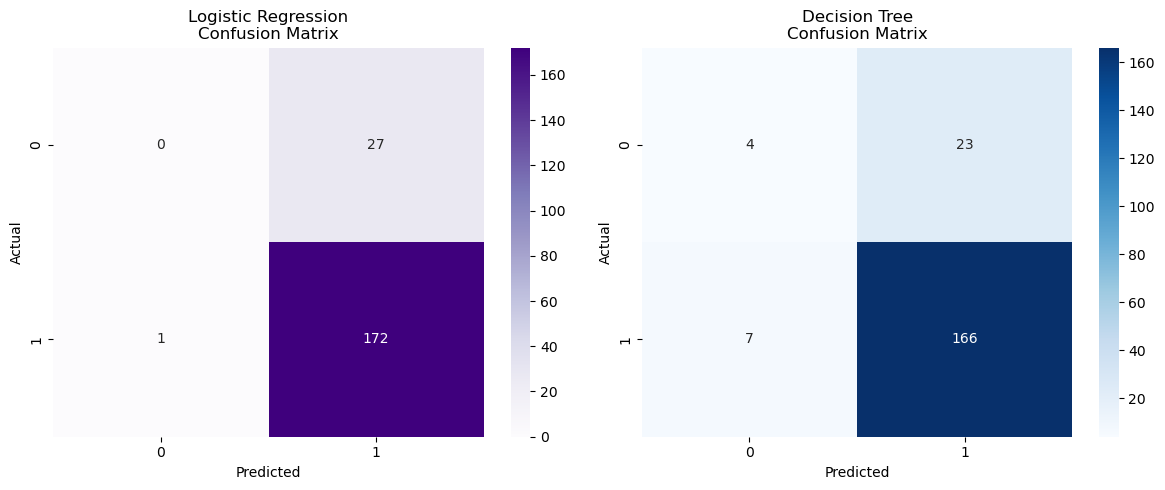

In [7]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm1 = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
cm2 = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Decision Tree\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()